In [1]:
# initiation
import warnings
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import constrNMPy
import os
from matplotlib import gridspec
from scipy import sparse, special, stats

%config InlineBackend.figure_format = 'retina'
warnings.simplefilter(action="ignore", category=FutureWarning)

# os.getcwd() 
# os.chdir('/Users/abel/Desktop/Project DFI/Exp2_data/DFI_2_Analysis/tables_dfi2') # change the working directory to the folder where the data is stored

# color pallette
[gr,ye,re,bl,pu,ir,ak] = ['#8ECFC9', '#FFBE7A', '#FA7F6F', '#82B0D2','#BEB8DC', '#E7DAD2','#999999']

# set the style of the plots
az.style.use("arviz-white")

# set the font
from matplotlib.font_manager import FontProperties

# 设置全局英文字体为 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# 设置全局中文字体为 'SimHei'
# plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 12
plt.rcParams['legend.loc'] = 'lower right'  # 'upper right', 'upper left', 'lower left', 'lower right', 'right'
plt.rcParams['axes.titlelocation'] = 'left'  # 'left', 'center', 'right'
plt.rcParams['axes.titley'] = 1.05  # 根据需要调整y的位置
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['ytick.left'] = True

In [32]:
# 直接从db文件导入数据和变量

import dill
dill.load_session('Exp_2_Data.db')

### Fig1 各个Inducer条件下的Target正确率与反应时

In [2]:
using_lst = [1,2,3,5,6,7,8,9,10,11,12]
use_num = len(using_lst)

T1_num = np.zeros((use_num,3))
T2_num = np.zeros((use_num,3))
T1_acc = np.zeros((use_num,3))
T2_acc = np.zeros((use_num,3))
T1_RT = np.zeros((use_num,3))
T2_RT = np.zeros((use_num,3))

for i in range(1,use_num+1):
    id = using_lst[i-1]
    currentdata = pd.read_excel('Exp_2_Data.xlsx',sheet_name='Sheet'+str(id))
    dt = currentdata.copy()
    
    T1B0 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 0)]
    T1B1 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 1)]
    T1B2 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 2)]
    
    T2B0 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 0)]
    T2B1 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 1)]
    T2B2 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 2)]
    
    T1_acc[i-1,:] = [T1B0['mean_RespAcc'].mean(),T1B1['mean_RespAcc'].mean(),T1B2['mean_RespAcc'].mean()]
    T2_acc[i-1,:] = [T2B0['mean_RespAcc'].mean(),T2B1['mean_RespAcc'].mean(),T2B2['mean_RespAcc'].mean()]
    T1_RT[i-1,:] = [T1B0['mean_RT'].mean()-0.15,T1B1['mean_RT'].mean(),T1B2['mean_RT'].mean()]
    T2_RT[i-1,:] = [T2B0['mean_RT'].mean(),T2B1['mean_RT'].mean(),T2B2['mean_RT'].mean()]
    T1_num[i-1,:] = [T1B0['mean_RespNum'].mean(),T1B1['mean_RespNum'].mean(),T1B2['mean_RespNum'].mean()]
    T2_num[i-1,:] = [T2B0['mean_RespNum'].mean(),T2B1['mean_RespNum'].mean(),T2B2['mean_RespNum'].mean()]
    
 

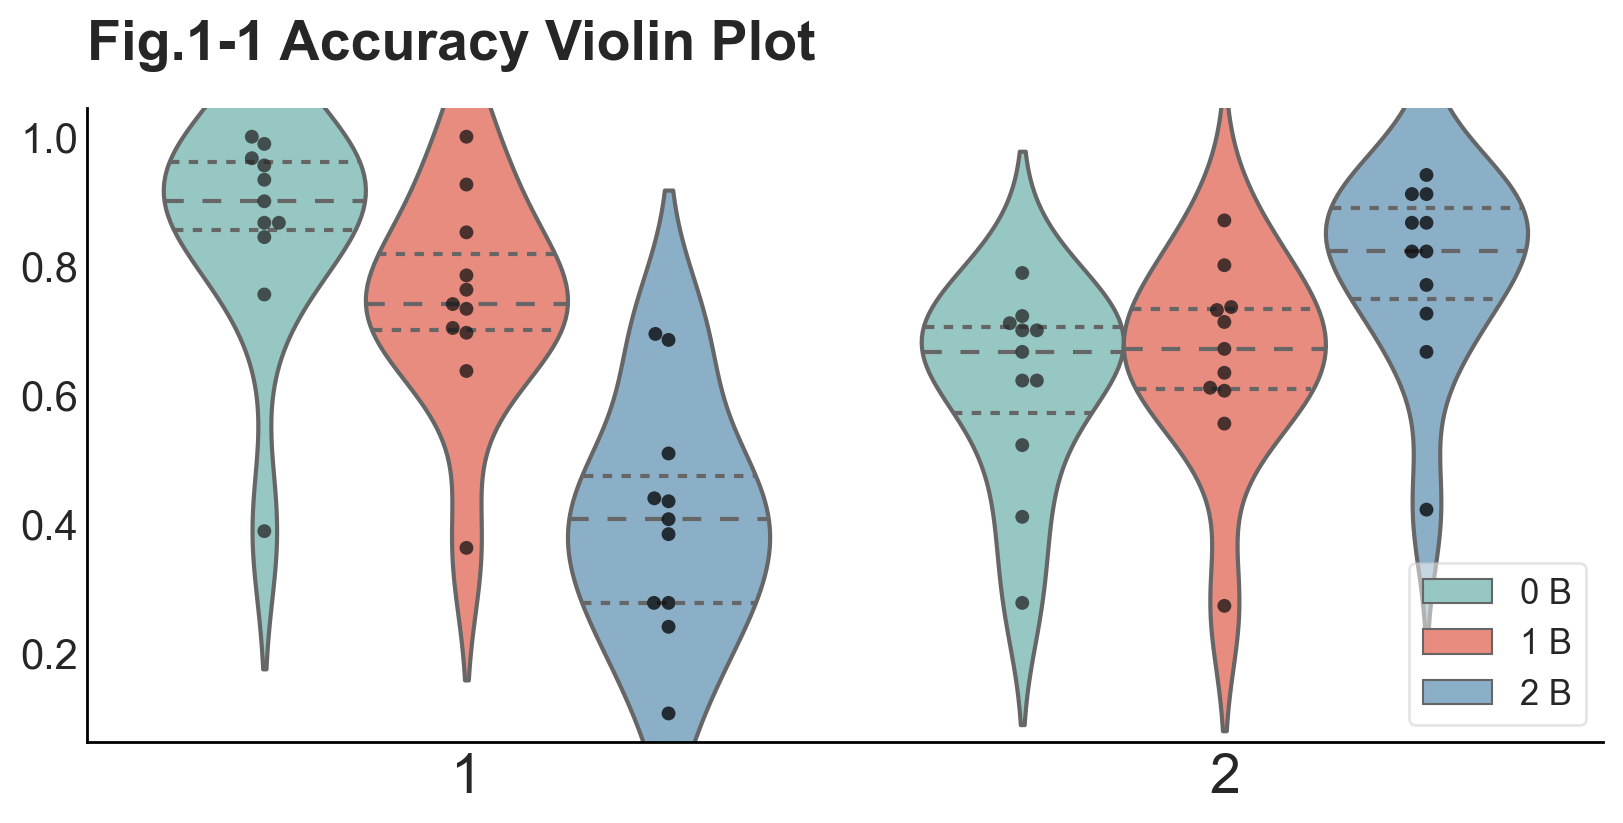

In [8]:
data1 = T1_acc
data2 = T2_acc
df1 = pd.DataFrame(data1, columns=['0 B', '1 B', '2 B'])
df1['Target'] = '1 Flash'
df2 = pd.DataFrame(data2, columns=['0 B', '1 B', '2 B'])
df2['Target'] = '2 Flashes'
df = pd.concat([df1, df2])
df_melted = df.melt(id_vars='Target', var_name='Beep', value_name='Accuracy')

plt.figure(figsize=(8,4))
plt.axes_edgecolor = 'black'
sns.violinplot(x='Target', y='Accuracy', hue='Beep', data=df_melted, inner='quartile', palette=[gr, re, bl], scale='width')
sns.swarmplot(x='Target', y='Accuracy', hue='Beep', data=df_melted, color='k',alpha = 0.75, size=5, dodge=True, legend=False)
plt.legend(loc='lower right', title='', fontsize='small', frameon=True, framealpha=0.5, fancybox=True)
plt.xlabel('')
plt.xticks([0,1],['1','2'],fontsize=20)
plt.yticks(fontsize = 15)
plt.ylabel('')
plt.title('Fig.1-1 Accuracy Violin Plot', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.show()


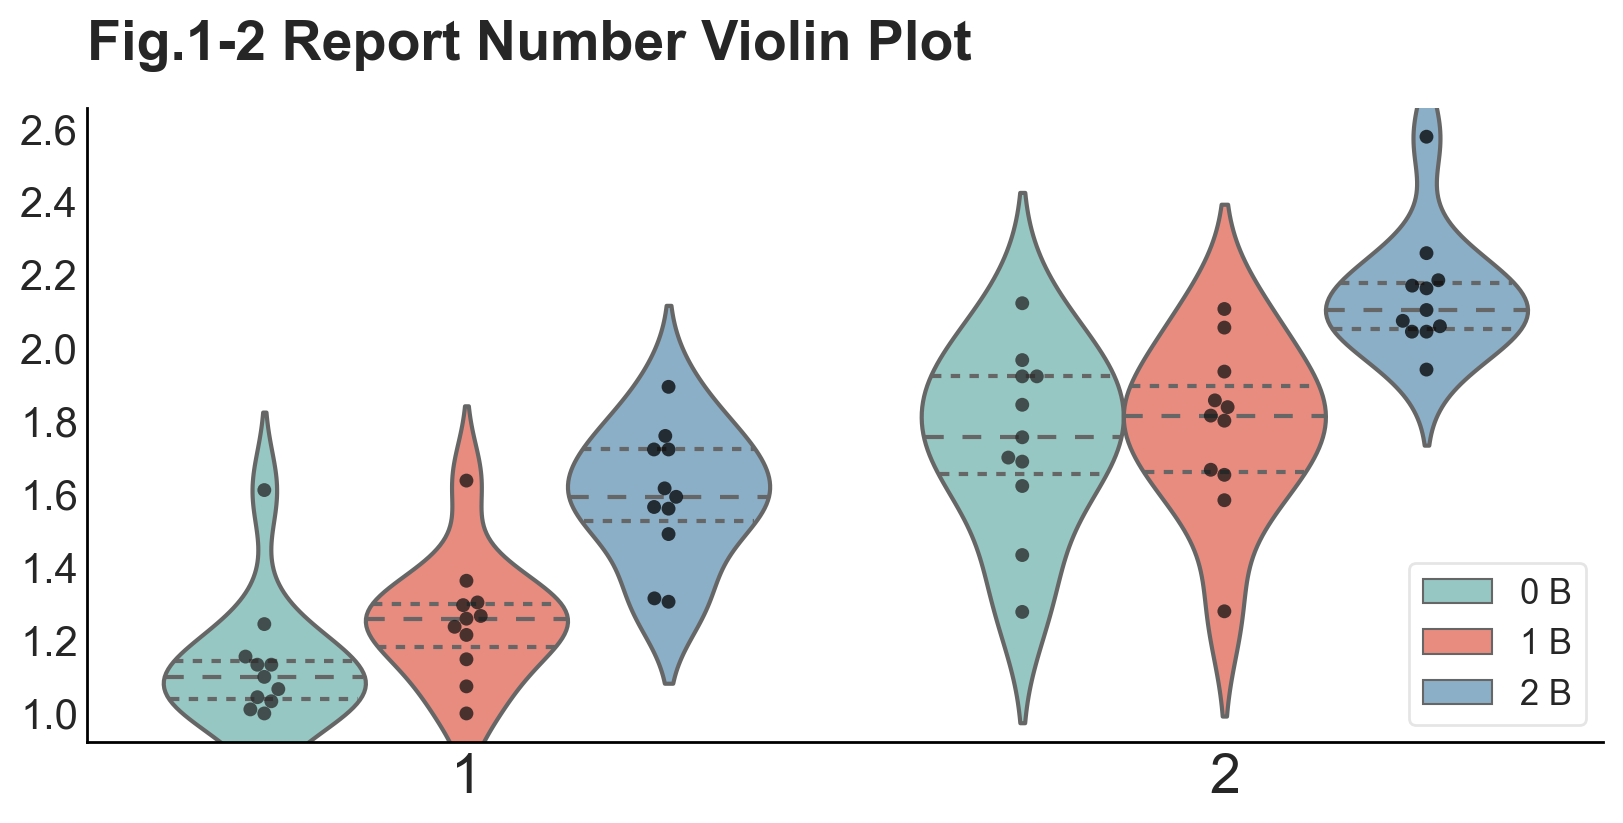

In [9]:
data1 = T1_num
data2 = T2_num
df1 = pd.DataFrame(data1, columns=['0 B', '1 B', '2 B'])
df1['Target'] = '1'
df2 = pd.DataFrame(data2, columns=['0 B', '1 B', '2 B'])
df2['Target'] = '2'
df = pd.concat([df1, df2])
df_melted = df.melt(id_vars='Target', var_name='Beep', value_name='Reported Number')

plt.figure(figsize=(8,4))
plt.axes_edgecolor = 'black'
sns.violinplot(x='Target', y='Reported Number', hue='Beep', data=df_melted, inner='quartile', palette=[gr, re, bl], scale='width')
legend = plt.legend(loc='upper right', title='', fontsize='large', frameon=True, framealpha=0.5, fancybox=True)
sns.swarmplot(x='Target', y='Reported Number', hue='Beep', data=df_melted, color='k',alpha = 0.75, size=5, dodge=True, legend=False)
plt.legend(loc='lower right', title='', fontsize='small', frameon=True, framealpha=0.5, fancybox=True)
plt.xlabel('')
plt.xticks([0,1],['1','2'],fontsize=20)
plt.yticks(fontsize = 15)
plt.ylabel('')
plt.title('Fig.1-2 Report Number Violin Plot', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.show()

数据导出至csv文件，在JASP中进行后续分析

导出数据为"DFI_2_1.csv"

In [7]:
subjects = np.arange(1,use_num+1)
subjects_repeat = np.tile(subjects,6)
df_melted['Subject'] = subjects_repeat
df_pivot = df_melted.pivot_table(index='Subject', columns=['Target', 'Beep'], values='Reported Number')
df_pivot.columns = df_pivot.columns.map('{0[0]}_{0[1]}'.format)
# df_pivot.to_csv('DFI_2_1.csv')
# df_melted

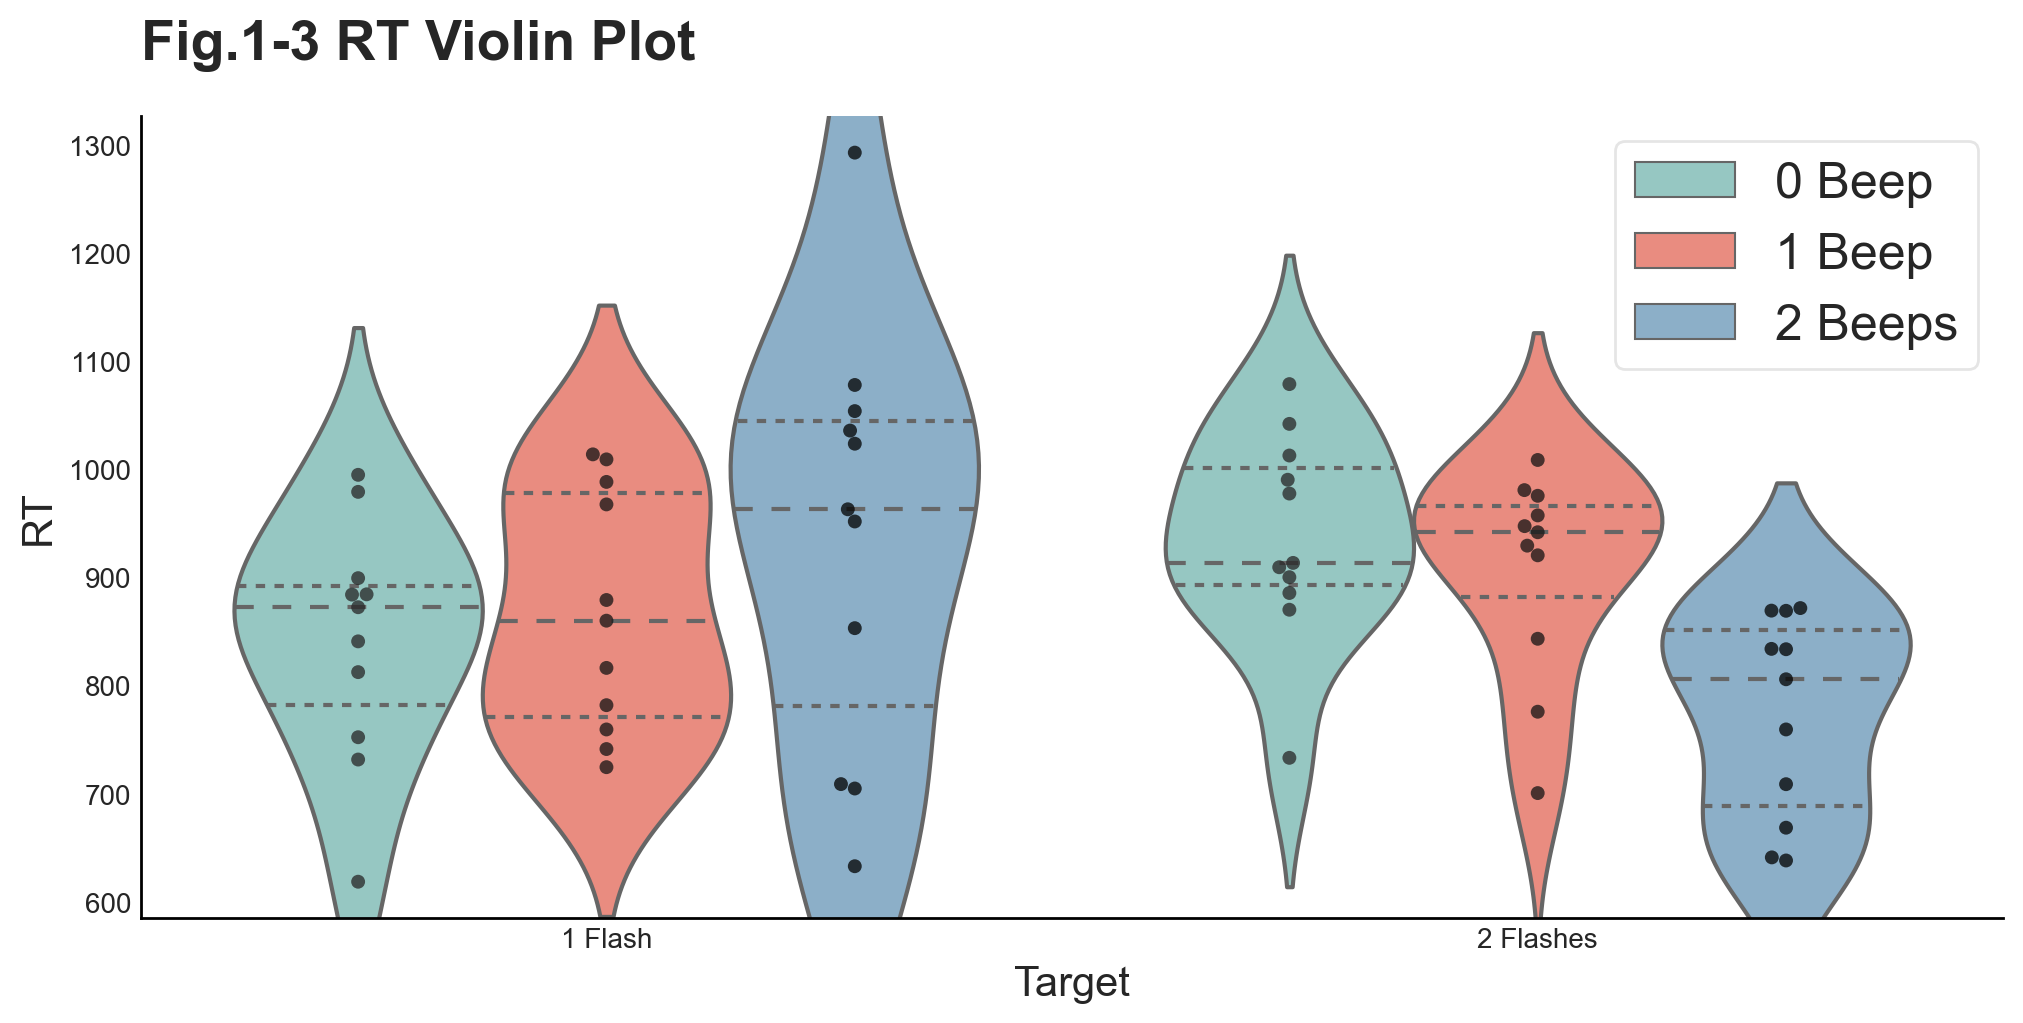

In [10]:
data1 = T1_RT * 1000
data2 = T2_RT * 1000
df1 = pd.DataFrame(data1, columns=['0 Beep', '1 Beep', '2 Beeps'])
df1['Target'] = '1 Flash'
df2 = pd.DataFrame(data2, columns=['0 Beep', '1 Beep', '2 Beeps'])
df2['Target'] = '2 Flashes'
df = pd.concat([df1, df2])
df_melted = df.melt(id_vars='Target', var_name='Beep', value_name='RT')

plt.figure(figsize=(10,5))
plt.axes_edgecolor = 'black'
sns.violinplot(x='Target', y='RT', hue='Beep', data=df_melted, inner='quartile', palette=[gr, re, bl], scale='width')
legend = plt.legend(loc='upper right', title='', fontsize='large', frameon=True, framealpha=0.5, fancybox=True)
sns.swarmplot(x='Target', y='RT', hue='Beep', data=df_melted, color='k',alpha = 0.75, size=5, dodge=True, legend=False)

plt.title('Fig.1-3 RT Violin Plot', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.show()

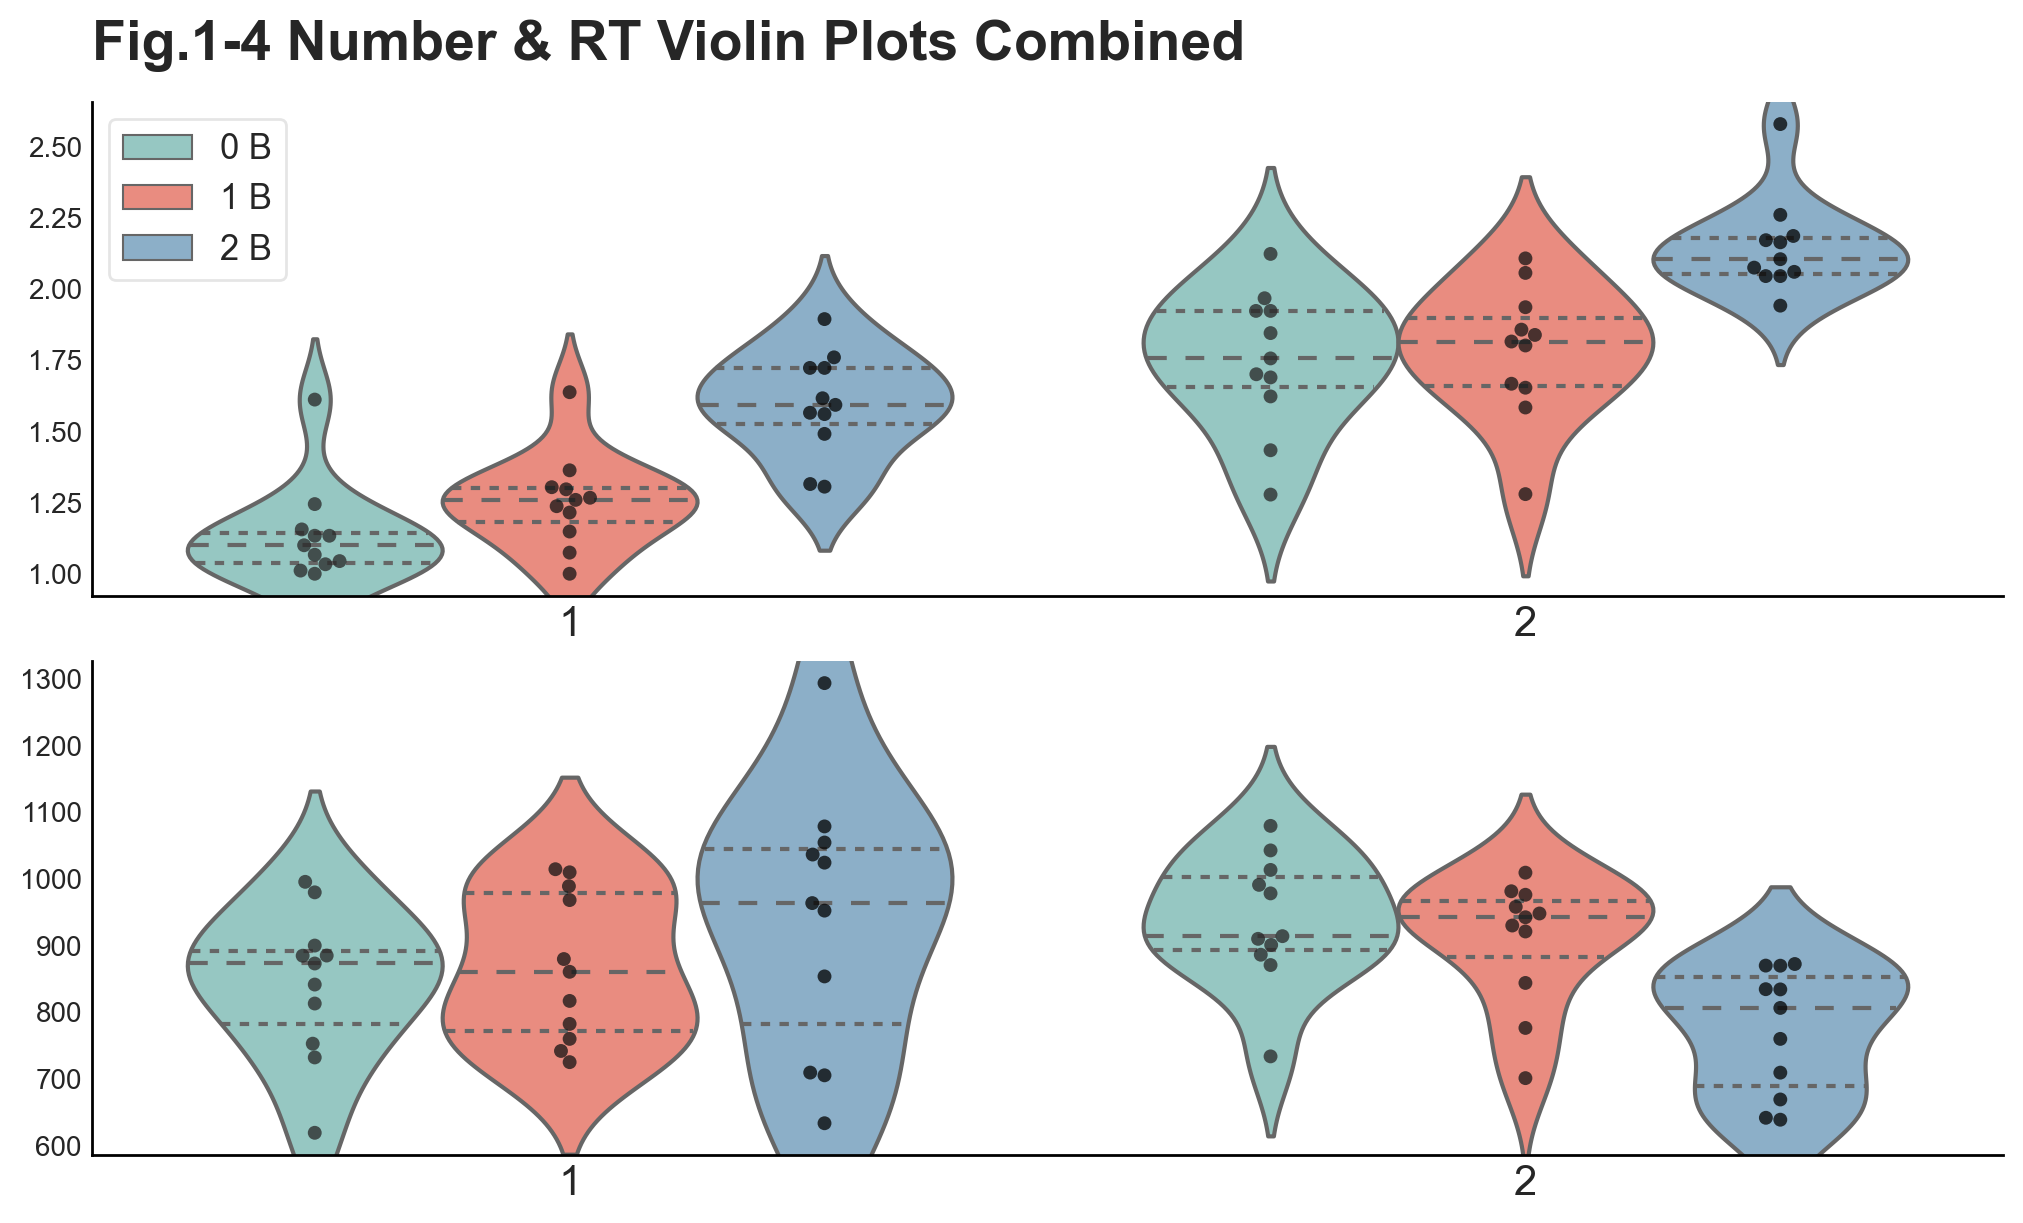

In [11]:
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
data1 = T1_num
data2 = T2_num
df1 = pd.DataFrame(data1, columns=['0 B', '1 B', '2 B'])
df1['Target'] = '1'
df2 = pd.DataFrame(data2, columns=['0 B', '1 B', '2 B'])
df2['Target'] = '2'
df = pd.concat([df1, df2])
df_melted = df.melt(id_vars='Target', var_name='Beep', value_name='Reported Number')
sns.violinplot(x='Target', y='Reported Number', hue='Beep', data=df_melted, inner='quartile', palette=[gr, re, bl], scale='width')
legend = plt.legend(loc='upper right', title='', fontsize='large', frameon=True, framealpha=0.5, fancybox=True)
sns.swarmplot(x='Target', y='Reported Number', hue='Beep', data=df_melted, color='k',alpha = 0.75, size=5, dodge=True, legend=False)
plt.legend(loc='upper left', title='', fontsize='small', frameon=True, framealpha=0.5, fancybox=True)
plt.ylabel('')
plt.xlabel('')
plt.xticks([0,1],['1','2'],fontsize=15)
plt.title('Fig.1-4 Number & RT Violin Plots Combined', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')


plt.subplot(2,1,2)
data1 = T1_RT * 1000
data2 = T2_RT * 1000
df1 = pd.DataFrame(data1, columns=['0 B', '1 B', '2 B'])
df1['Target'] = '1'
df2 = pd.DataFrame(data2, columns=['0 B', '1 B', '2 B'])
df2['Target'] = '2'
df = pd.concat([df1, df2])
df_melted = df.melt(id_vars='Target', var_name='Beep', value_name='RT')

plt.axes_edgecolor = 'black'
sns.violinplot(x='Target', y='RT', hue='Beep', data=df_melted, inner='quartile', palette=[gr, re, bl], scale='width')
sns.swarmplot(x='Target', y='RT', hue='Beep', data=df_melted, color='k',alpha = 0.75, size=5, dodge=True)
plt.xlabel('')
plt.ylabel('')
plt.xticks([0,1],['1','2'],fontsize=15)
## hide the legend
plt.legend([],[], frameon=False)
plt.show()


### Fig2 Effect of eccentricity on target accuracy and reaction time

比较不同条件下知觉的正确率，寻找Eccentricity Effect




In [2]:
using_lst = [1,2,3,5,6,7,8,9,10,11,12]
use_num = len(using_lst)

T1B0_ecc = np.zeros((use_num, 9))
T1B1_ecc = np.zeros((use_num, 9))
T1B2_ecc = np.zeros((use_num, 9))
T2B0_ecc = np.zeros((use_num, 9))
T2B1_ecc = np.zeros((use_num, 9))
T2B2_ecc = np.zeros((use_num, 9))
T1B2_ecc_40 = np.zeros((use_num,9))
T1B2_ecc_70 = np.zeros((use_num,9))

T1B0_ecc_RT = np.zeros((use_num, 9))
T1B1_ecc_RT = np.zeros((use_num, 9))
T1B2_ecc_RT = np.zeros((use_num, 9))
T2B0_ecc_RT = np.zeros((use_num, 9))
T2B1_ecc_RT = np.zeros((use_num, 9))
T2B2_ecc_RT = np.zeros((use_num, 9))

T1B0_ecc_num = np.zeros((use_num, 9))
T1B1_ecc_num = np.zeros((use_num, 9))
T1B2_ecc_num = np.zeros((use_num, 9))
T2B0_ecc_num = np.zeros((use_num, 9))
T2B1_ecc_num = np.zeros((use_num, 9))
T2B2_ecc_num = np.zeros((use_num, 9))
T1B2_ecc_num_40 = np.zeros((use_num,9))
T1B2_ecc_num_70 = np.zeros((use_num,9))


for i in range(1, use_num+1):
    id = using_lst[i-1]
    currentdata = pd.read_excel('Exp_2_Data.xlsx',sheet_name='Sheet'+str(id))
    dt = currentdata.copy()
    
    T1B0 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 0)]
    T1B1 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 1)]
    T1B2 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 2)]
    T1B2_40 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 2) & (dt['SOA'] == 40)]
    T1B2_70 = dt[(dt['TargetNum'] == 1) & (dt['InducerNum'] == 2) & (dt['SOA'] == 70)]
    T2B1 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 1)]
    T2B0 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 0)]
    
    T1B0_ecc[i-1,:] = T1B0['mean_RespAcc'].values
    T1B1_ecc[i-1,:] = T1B1['mean_RespAcc'].values
    T1B0_ecc_RT[i-1,:] = T1B0['mean_RT'].values
    T1B1_ecc_RT[i-1,:] = T1B1['mean_RT'].values
    T1B0_ecc_num[i-1,:] = T1B0['mean_RespNum'].values
    T1B1_ecc_num[i-1,:] = T1B1['mean_RespNum'].values
        
    T2B2 = dt[(dt['TargetNum'] == 2) & (dt['InducerNum'] == 2)]
    T2B2_ecc[i-1,:] = T2B2['mean_RespAcc'].values
    T2B2_ecc_RT[i-1,:] = T2B2['mean_RT'].values
    T2B2_ecc_num[i-1,:] = T2B2['mean_RespNum'].values
    

    for j in range(9):
        T1B2_ecc[i-1,j] = np.mean(T1B2[T1B2['TargetPos'] == j+1]['mean_RespAcc'].values)
        T2B1_ecc[i-1,j] = np.mean(T2B1[T2B1['TargetPos'] == j+1]['mean_RespAcc'].values)
        T2B0_ecc[i-1,j] = np.mean(T2B0[T2B0['TargetPos'] == j+1]['mean_RespAcc'].values)
        T1B2_ecc_40[i-1,j] = np.mean(T1B2_40[T1B2_40['TargetPos'] == j+1]['mean_RespAcc'].values)
        T1B2_ecc_70[i-1,j] = np.mean(T1B2_70[T1B2_70['TargetPos'] == j+1]['mean_RespAcc'].values)
        
        T1B2_ecc_RT[i-1,j] = np.mean(T1B2[T1B2['TargetPos'] == j+1]['mean_RT'].values)
        T2B1_ecc_RT[i-1,j] = np.mean(T2B1[T2B1['TargetPos'] == j+1]['mean_RT'].values)
        T2B0_ecc_RT[i-1,j] = np.mean(T2B0[T2B0['TargetPos'] == j+1]['mean_RT'].values)
        
        T1B2_ecc_num[i-1,j] = np.mean(T1B2[T1B2['TargetPos'] == j+1]['mean_RespNum'].values)
        T2B1_ecc_num[i-1,j] = np.mean(T2B1[T2B1['TargetPos'] == j+1]['mean_RespNum'].values)
        T2B0_ecc_num[i-1,j] = np.mean(T2B0[T2B0['TargetPos'] == j+1]['mean_RespNum'].values)  
        T1B2_ecc_num_40[i-1,j] = np.mean(T1B2_40[T1B2_40['TargetPos'] == j+1]['mean_RespNum'].values)
        T1B2_ecc_num_70[i-1,j] = np.mean(T1B2_70[T1B2_70['TargetPos'] == j+1]['mean_RespNum'].values)

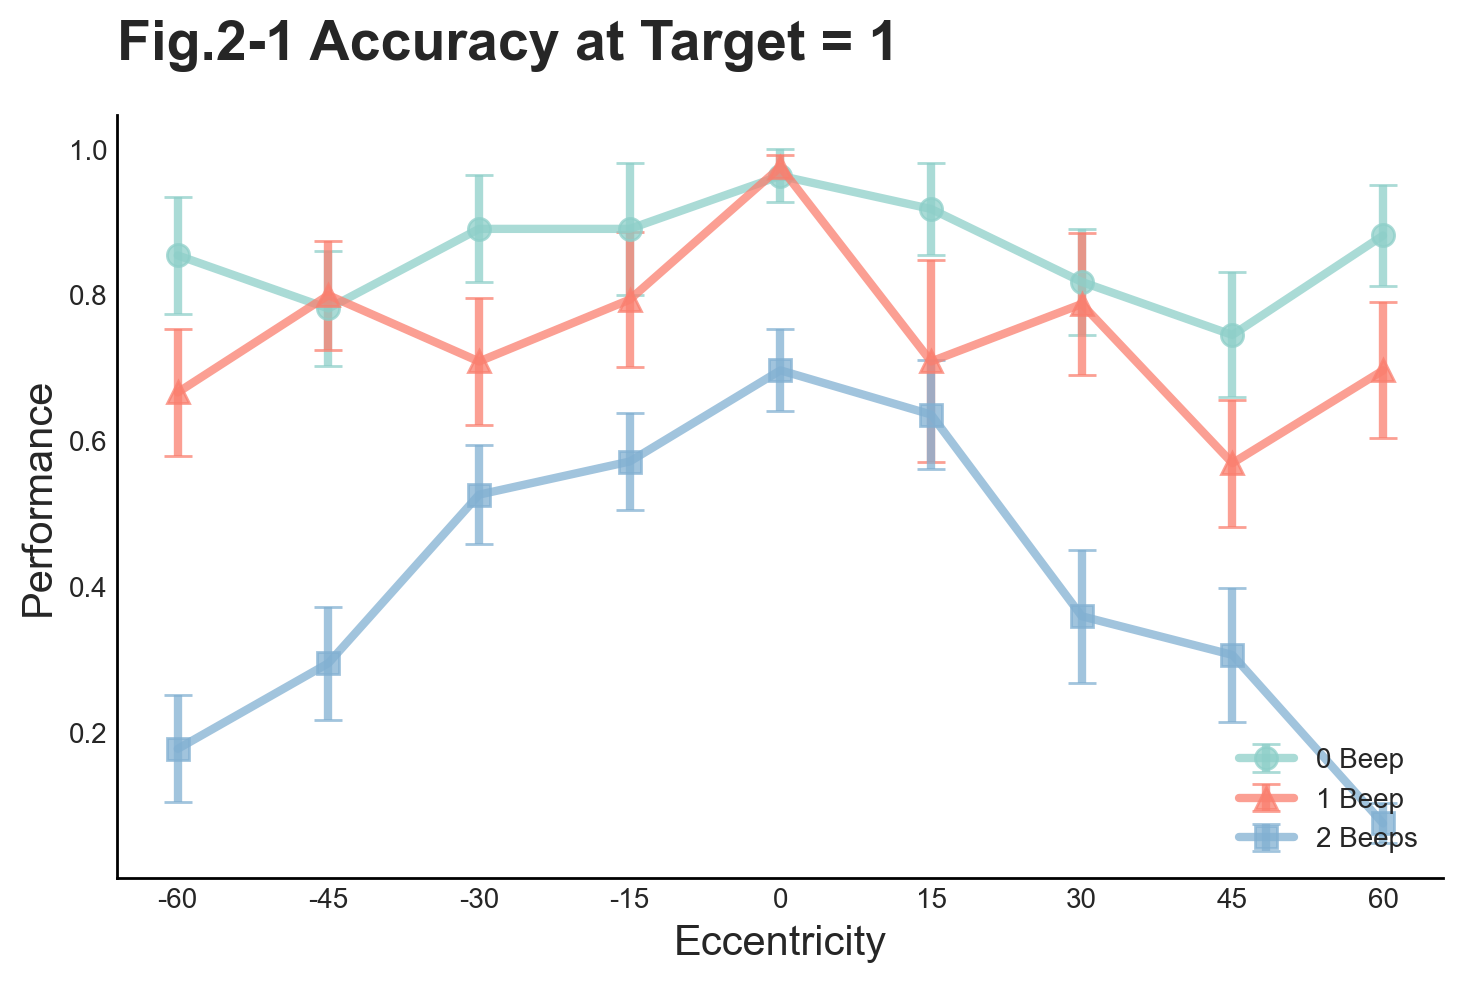

In [20]:
## Draw plots at Target = 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T1B0_ecc
data2 = T1B1_ecc
data3 = T1B2_ecc


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 Beep', capsize=5, color = gr, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 Beep', capsize=5, color = re, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 Beeps', capsize=5, color = bl, alpha = 0.75, linewidth = 3, markersize = 8)
plt.title('Fig.2-1 Accuracy at Target = 1', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('Eccentricity')
plt.ylabel('Performance')
plt.xticks(x, [-60, -45, -30, -15, 0, 15, 30, 45, 60])
plt.legend()
plt.show()


由于正确率存在高斯曲线的趋势，对正确率进行高斯曲线拟合

For SOA = 40 ms:
Parameters: [-4.0463761  33.63019783  0.68171013]
Adjusted R squared: 0.9327560695238194
------
For SOA = 70 ms:
Parameters: [-1.41380924 33.74811652  0.67613955]
Adjusted R squared: 0.902686886596722
------
For Averaged:
Parameters: [-2.739188   33.74775998  0.67808646]
Adjusted R squared: 0.9222794256198619
------


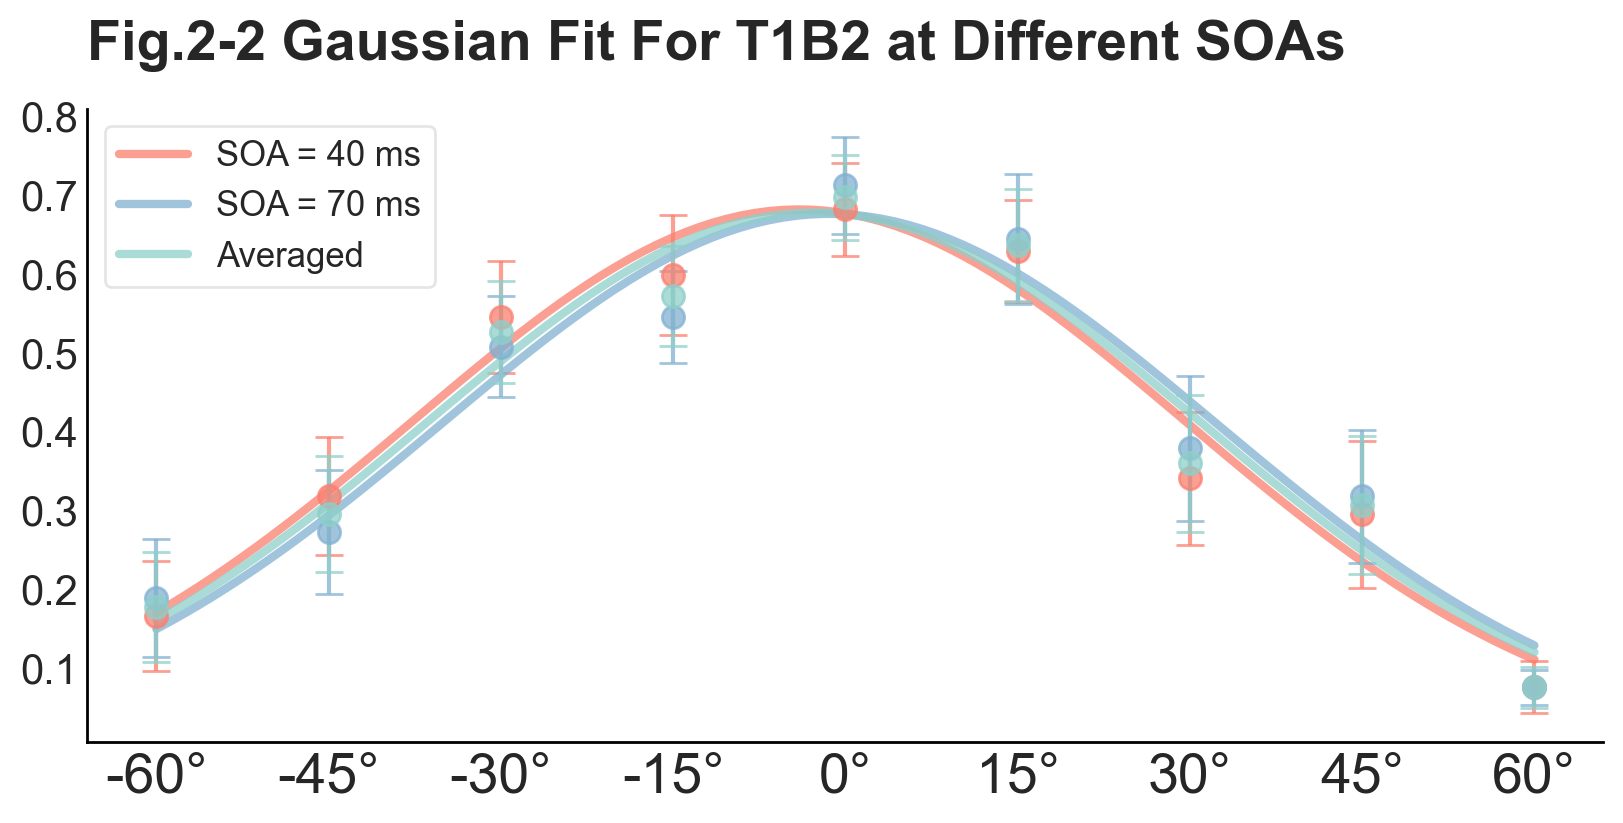

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

T1B2_acc = T1B2_ecc
T1B2_ecc = np.array([-60, -45, -30, -15, 0, 15, 30, 45, 60])

plt.figure(figsize=(8,4))

def Gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def fit_and_plot(data, color, label):
    # Initial guess
    mean_data = np.mean(data, axis=0)
    A_guess = max(mean_data)
    mu_guess = T1B2_ecc[np.argmax(mean_data)]
    sigma_guess = np.std(T1B2_ecc)
    popt, pcov = curve_fit(Gauss, T1B2_ecc, mean_data, p0=[mu_guess, sigma_guess, A_guess])
    
    # Plot fitting curve
    x = np.linspace(-60, 60, 100)
    y = Gauss(x, *popt)
    plt.plot(x, y, color, label=label, linewidth=3, alpha=0.75)
    se = np.std(data, axis=0) / np.sqrt(data.shape[0])
    plt.errorbar(T1B2_ecc, mean_data, yerr=se, fmt='o', color=color, capsize=5, alpha=0.75, markersize=8)
    
    # calculate R square
    residuals = mean_data - Gauss(T1B2_ecc, *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((mean_data-np.mean(mean_data))**2)
    r_squared = 1 - (ss_res / ss_tot)
    r_squared_adj = 1 - (1-r_squared)*(len(mean_data)-1)/(len(mean_data)-len(popt)-1)
    
    print(f"For {label}:")
    print("Parameters:", popt)
    print("Adjusted R squared:", r_squared_adj)
    print("------")

# Fit and plot for both datasets
fit_and_plot(T1B2_ecc_40, re, 'SOA = 40 ms')
fit_and_plot(T1B2_ecc_70, bl, 'SOA = 70 ms')
fit_and_plot(T1B2_acc, gr, 'Averaged')

plt.title('Fig.2-2 Gaussian Fit For T1B2 at Different SOAs', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('')
plt.xticks(T1B2_ecc, ['-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°'],fontsize=20)
plt.legend(loc='upper left', title='', fontsize='small', frameon=True, framealpha=0.5, fancybox=True)
plt.yticks(fontsize = 15)
plt.ylabel('')
plt.show()


数据导出至csv文件，在JASP中进行后续分析

导出数据为"DFI_2_3.csv"

In [22]:
Eccs = ['-60', '-45', '-30', '-15', '0', '15', '30', '45', '60']
df_40 = pd.DataFrame(T1B2_ecc_num_40, columns=Eccs)
df_70 = pd.DataFrame(T1B2_ecc_num_70, columns=Eccs)

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Combine the data from both dataframes
df = pd.concat([df_40, df_70], keys=['40', '70'], names=['Variable B'])

# Reshape the data for the ANOVA test
df_melt = pd.melt(df.reset_index(), id_vars=['Variable B'], value_vars=Eccs, var_name='Variable A', value_name='Value')
subjects = np.arange(1,use_num+1)
subjects_repeat = np.tile(subjects,18)
df_melt = df_melt.assign(Subject = subjects_repeat)
df_pivot = df_melt.pivot_table(index='Subject', columns=['Variable A', 'Variable B'], values='Value')
df_pivot.columns = df_pivot.columns.map('{0[0]}_{0[1]}'.format)
# df_pivot.to_csv('DFI_2_3.csv')

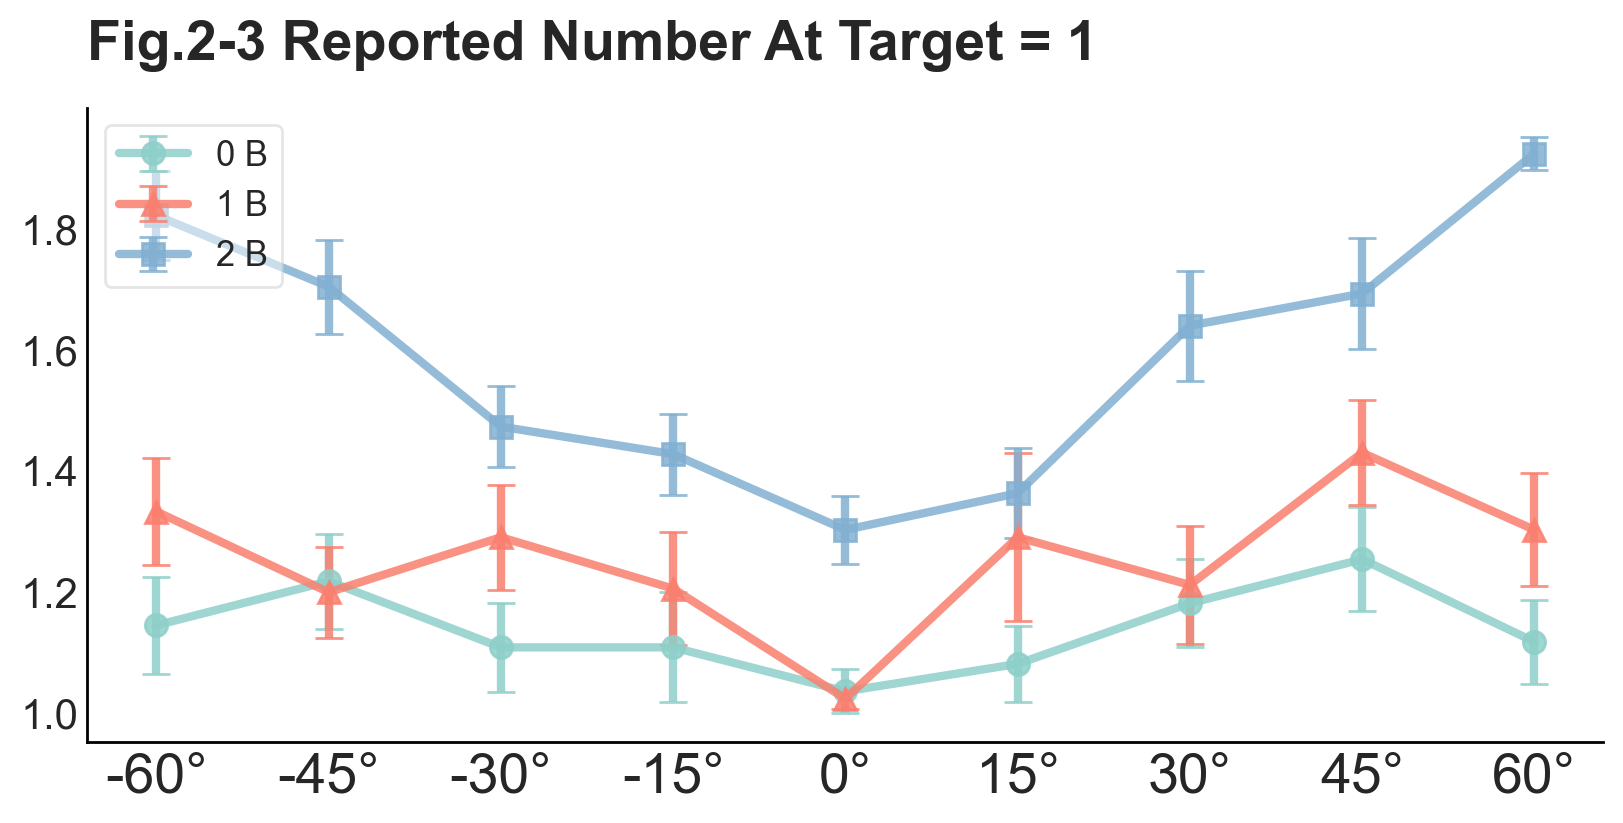

In [3]:
## Draw plots at Target = 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T1B0_ecc_num
data2 = T1B1_ecc_num
data3 = T1B2_ecc_num


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.figure(figsize=(8,4))
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 B', capsize=5, color = gr, alpha = 0.85, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 B', capsize=5, color = re, alpha = 0.85, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 B', capsize=5, color = bl, alpha = 0.85, linewidth = 3, markersize = 8)
plt.title('Fig.2-3 Reported Number At Target = 1', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('')
plt.xticks(x, ['-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°'],fontsize=20)
plt.legend(loc='upper left', title='', fontsize='small', frameon=True, framealpha=0.5, fancybox=True)
plt.yticks(fontsize = 15)
plt.ylabel('')
plt.show()


数据导出至csv文件，在JASP中进行后续分析

导出数据为"DFI_2_2.csv"

In [4]:
subjects = np.arange(1,use_num+1)
T1B0_ecc_num = pd.DataFrame(T1B0_ecc_num, columns=['-60', '-45', '-30', '-15', '0', '15', '30', '45', '60'])
T1B0_ecc_num['Subject'] = subjects
T1B0_ecc_num['Beep'] = 0
T1B1_ecc_num = pd.DataFrame(T1B1_ecc_num, columns=['-60', '-45', '-30', '-15', '0', '15', '30', '45', '60'])
T1B1_ecc_num['Subject'] = subjects
T1B1_ecc_num['Beep'] = 1
T1B2_ecc_num = pd.DataFrame(T1B2_ecc_num, columns=['-60', '-45', '-30', '-15', '0', '15', '30', '45', '60'])
T1B2_ecc_num['Subject'] = subjects
T1B2_ecc_num['Beep'] = 2

T1_combined = pd.concat([T1B0_ecc_num, T1B1_ecc_num, T1B2_ecc_num])
T1_combined_melted = T1_combined.melt(id_vars=['Subject', 'Beep'], var_name='Eccentricity', value_name='Reported Number')
T1_pivot = T1_combined_melted.pivot_table(index = 'Subject', columns = ['Beep', 'Eccentricity'], values = 'Reported Number')

T1_pivot.columns = T1_pivot.columns.map('{0[0]}_{0[1]}'.format)
# T1_pivot.to_csv('DFI_2_2.csv')

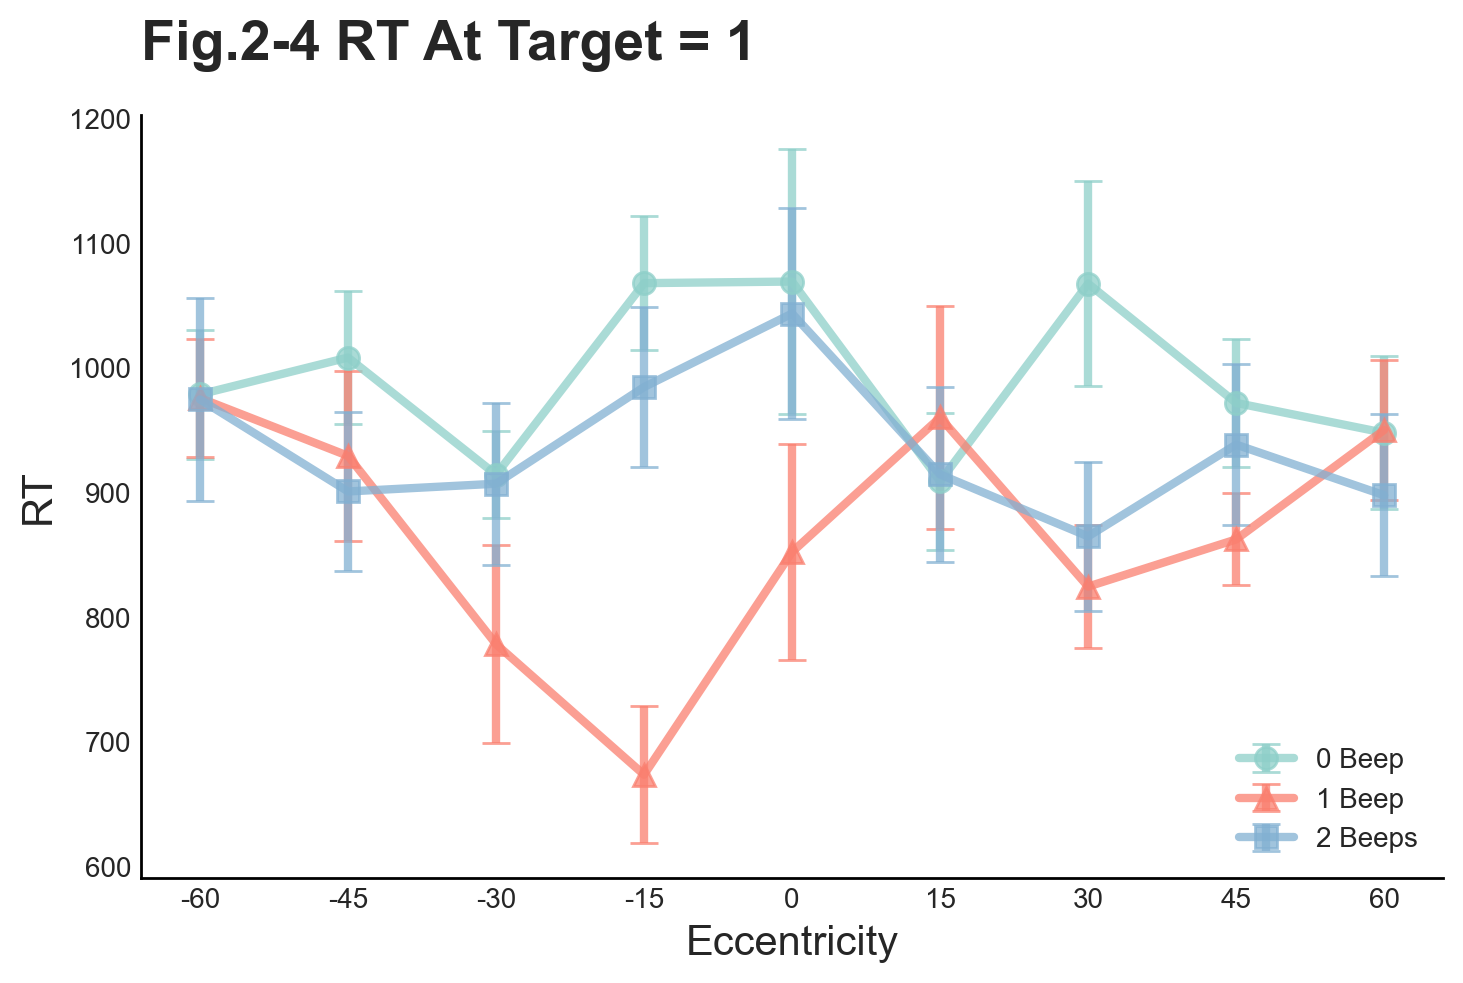

In [24]:
## Draw plots at Target = 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T1B0_ecc_RT * 1000
data2 = T1B1_ecc_RT * 1000
data3 = T1B2_ecc_RT * 1000


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 Beep', capsize=5, color = gr, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 Beep', capsize=5, color = re, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 Beeps', capsize=5, color = bl, alpha = 0.75, linewidth = 3, markersize = 8)
plt.title('Fig.2-4 RT At Target = 1', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('Eccentricity')
plt.ylabel('RT')
plt.xticks(x, [-60, -45, -30, -15, 0, 15, 30, 45, 60])
plt.legend()
plt.show()


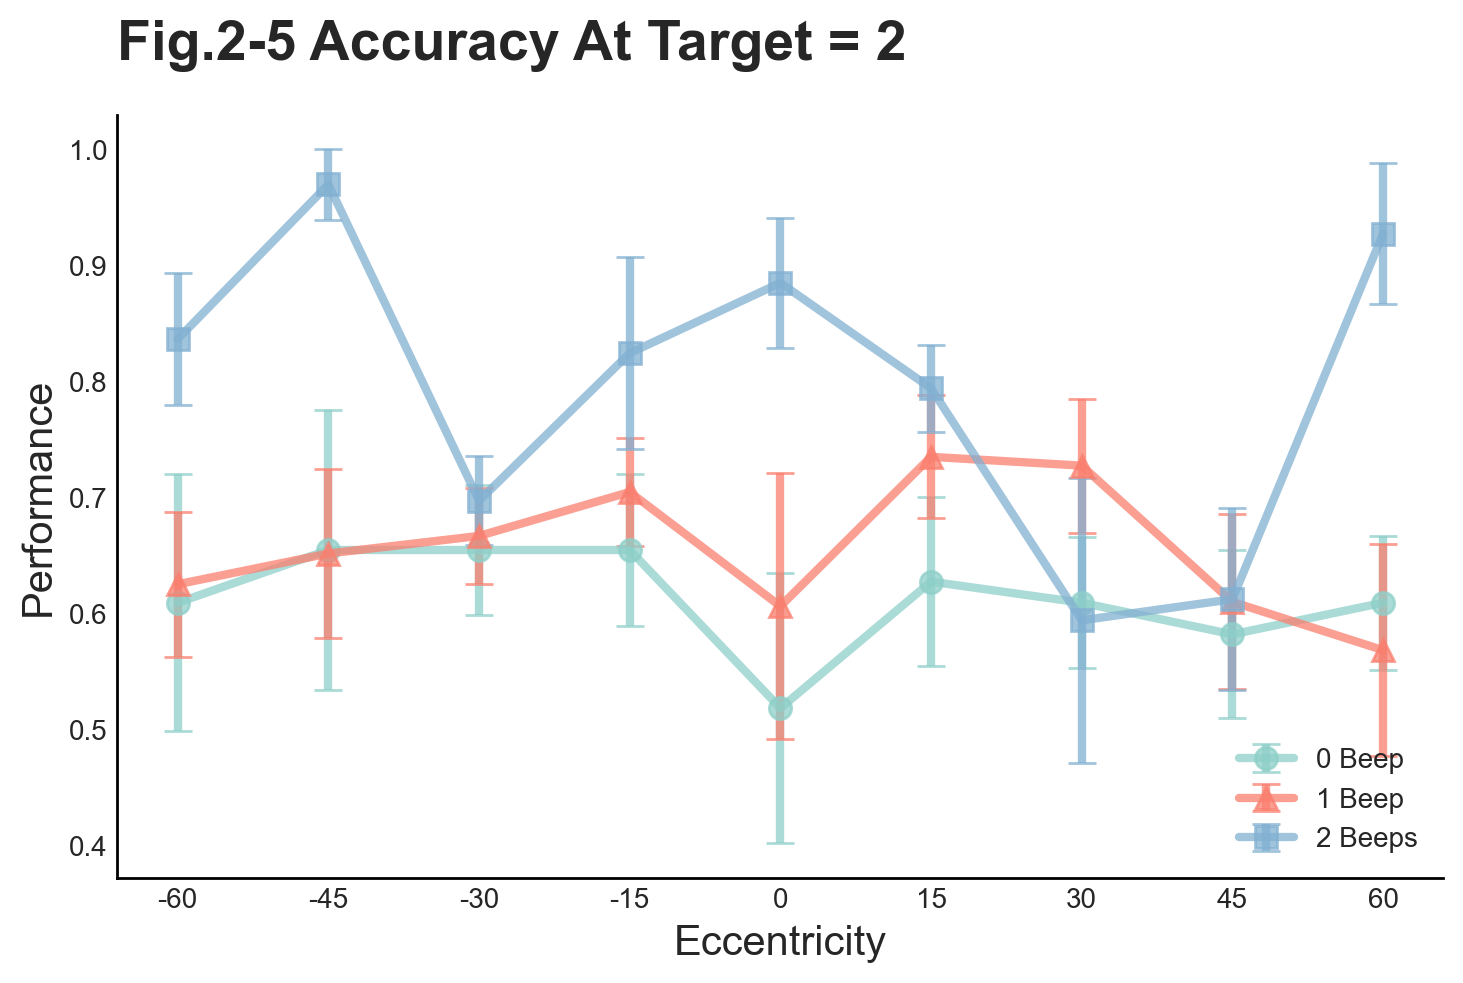

In [26]:
## Draw plots at Target = 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T2B0_ecc
data2 = T2B1_ecc
data3 = T2B2_ecc


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 Beep', capsize=5, color = gr, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 Beep', capsize=5, color = re, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 Beeps', capsize=5, color = bl, alpha = 0.75, linewidth = 3, markersize = 8)
plt.title('Fig.2-5 Accuracy At Target = 2', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('Eccentricity')
plt.ylabel('Performance')
plt.xticks(x, [-60, -45, -30, -15, 0, 15, 30, 45, 60])
plt.legend()
plt.show()


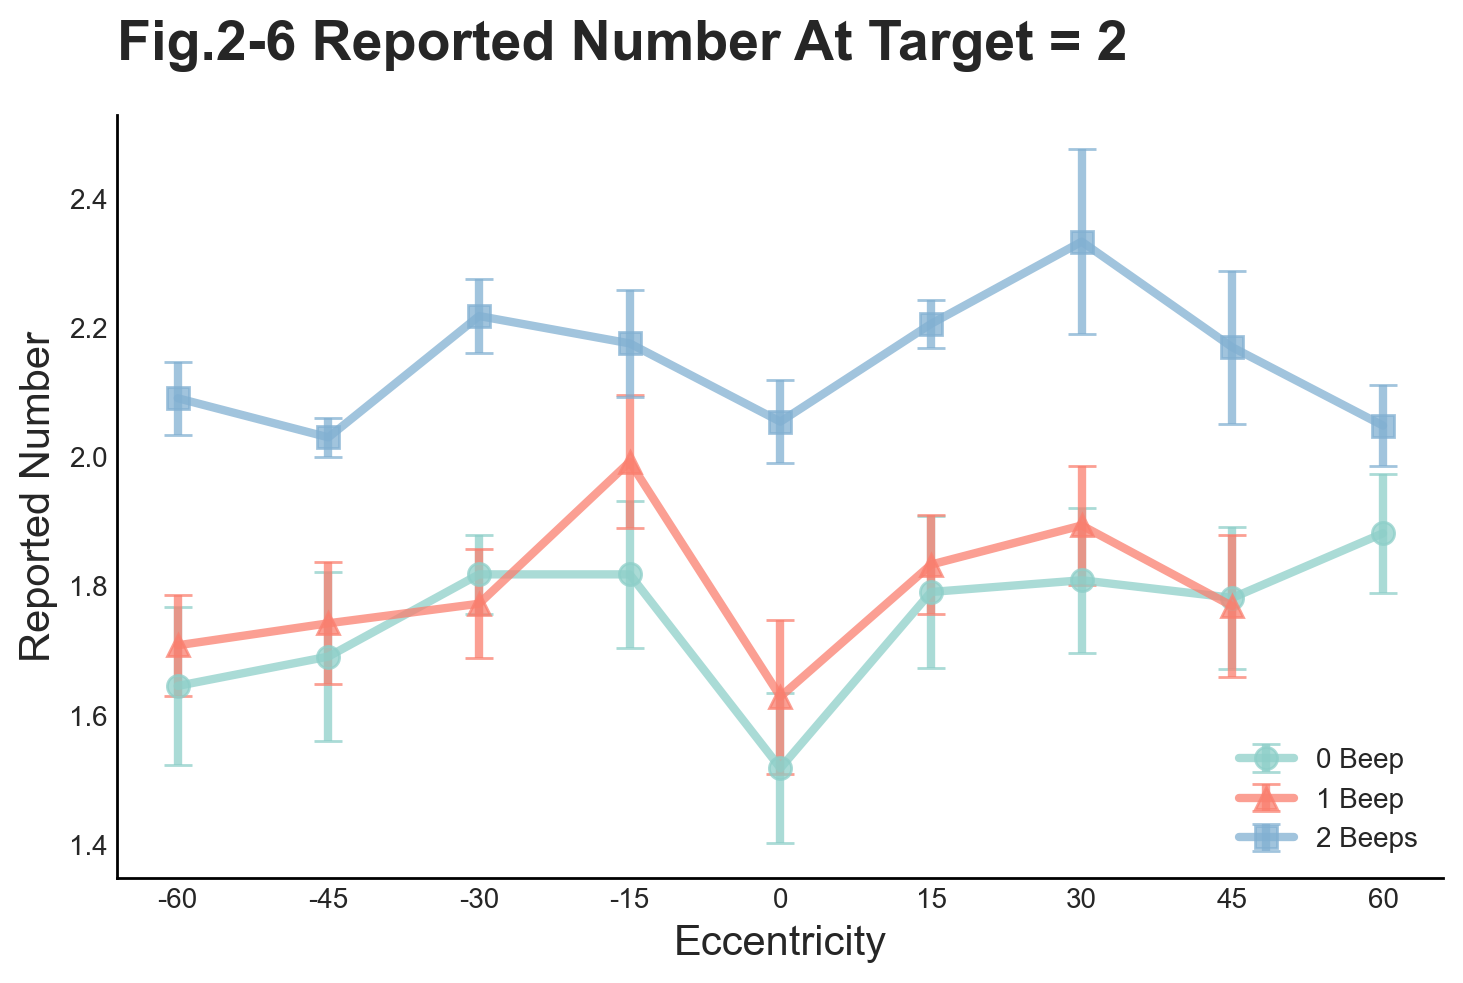

In [27]:
## Draw plots at Target = 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T2B0_ecc_num
data2 = T2B1_ecc_num
data3 = T2B2_ecc_num


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 Beep', capsize=5, color = gr, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 Beep', capsize=5, color = re, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 Beeps', capsize=5, color = bl, alpha = 0.75, linewidth = 3, markersize = 8)
plt.title('Fig.2-6 Reported Number At Target = 2', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('Eccentricity')
plt.ylabel('Reported Number')
plt.xticks(x, [-60, -45, -30, -15, 0, 15, 30, 45, 60])
plt.legend()
plt.show()


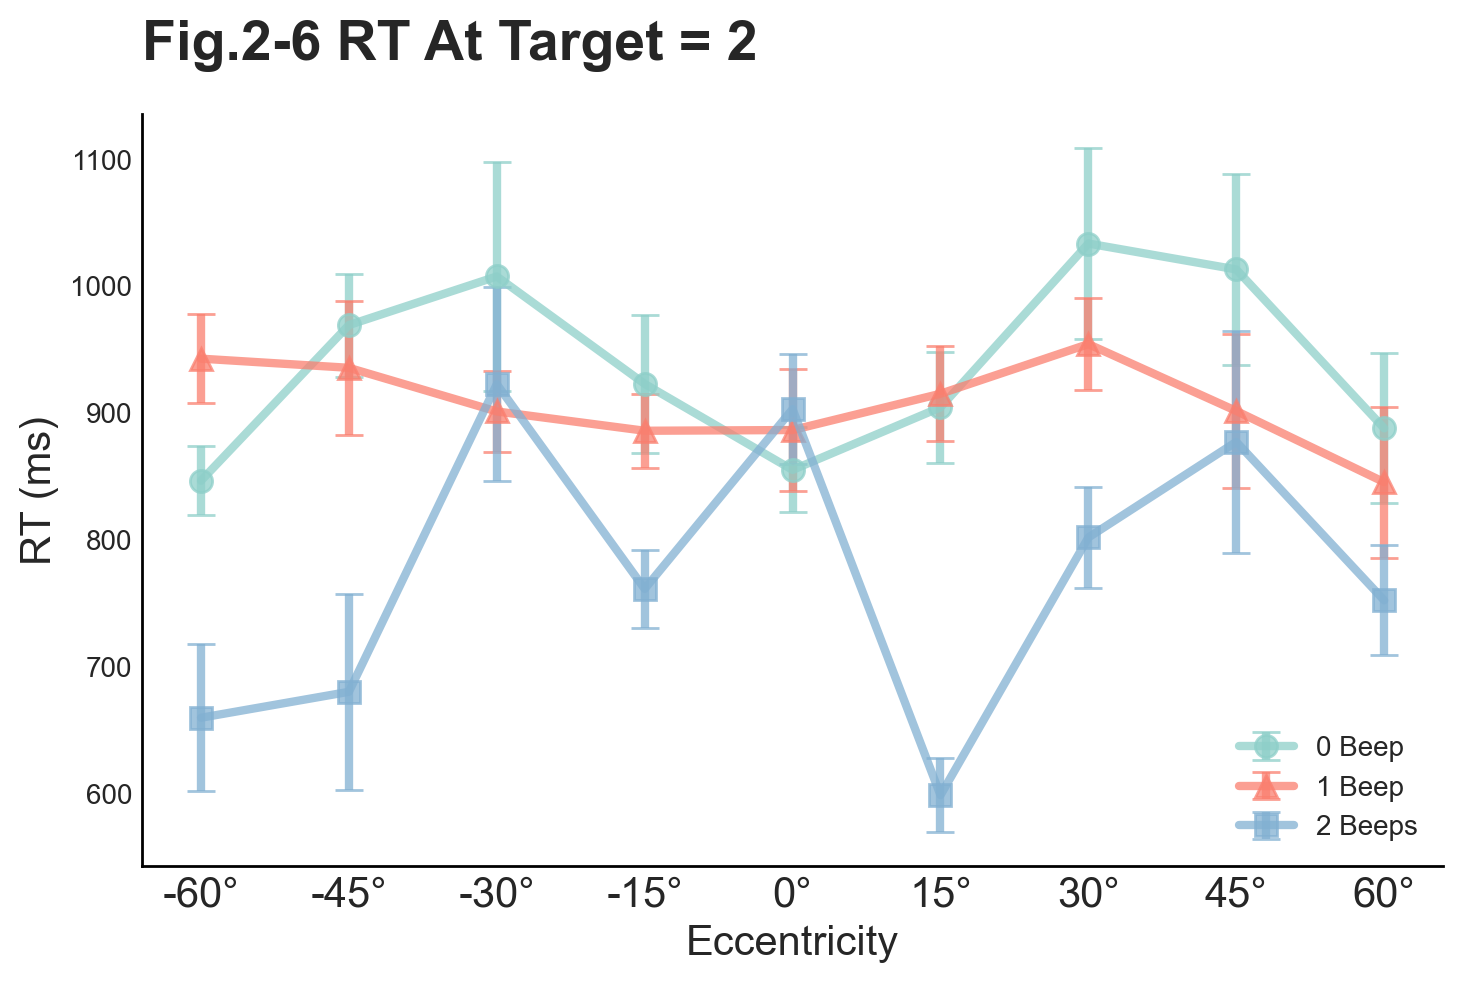

In [28]:
## Draw plots at Target = 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


data1 = T2B0_ecc_RT * 1000
data2 = T2B1_ecc_RT * 1000
data3 = T2B2_ecc_RT* 1000


x = np.arange(1, 10)
mean1 = np.mean(data1, axis=0)
stderr1 = sem(data1, axis=0)

mean2 = np.mean(data2, axis=0)
stderr2 = sem(data2, axis=0)

mean3 = np.mean(data3, axis=0)
stderr3 = sem(data3, axis=0)
plt.errorbar(x, mean1, yerr=stderr1, fmt='-o', label='0 Beep', capsize=5, color = gr, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean2, yerr=stderr2, fmt='-^', label='1 Beep', capsize=5, color = re, alpha = 0.75, linewidth = 3, markersize = 8)
plt.errorbar(x, mean3, yerr=stderr3, fmt='-s', label='2 Beeps', capsize=5, color = bl, alpha = 0.75, linewidth = 3, markersize = 8)
plt.title('Fig.2-6 RT At Target = 2', fontsize=20, fontweight='bold', y=1.05, fontfamily='Arial')
plt.xlabel('Eccentricity')
plt.ylabel('RT (ms)')
plt.xticks(x, ['-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°'],fontsize=15)
plt.legend()
plt.show()


In [30]:
import dill
dill.dump_session('Exp_2_Data.db')